## 1. Import  Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Training Dataset

We use the training dataset for Exploratory Data Analysis.

The value `na` is treated as a missing value.

In [2]:
train_df=pd.read_csv("../data/raw/aps_failure_training_set.csv",skiprows=20,na_values="na")

## 3. Copy the Dataset

In [3]:
df_eda = train_df.copy()

## 4. Check the Dataset Shape

In [4]:
df_eda.shape

(60000, 171)

## 5. Target Class Distribution

The target column is `class`.

- `neg` = No APS failure
- `pos` = APS failure

Let's visualize the number of observations in each class.

In [6]:
df_eda["class"].value_counts()

class
neg    59000
pos     1000
Name: count, dtype: int64

## 6. Target Class Percentage

In [7]:
df_eda["class"].value_counts(normalize=True)*100

class
neg    98.333333
pos     1.666667
Name: proportion, dtype: float64

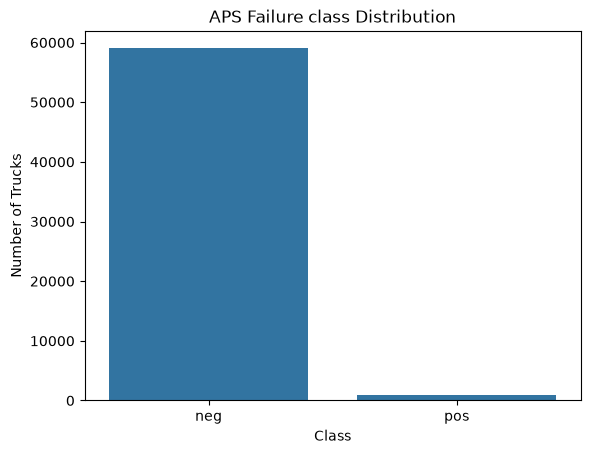

In [5]:
sns.countplot(data=df_eda,x="class")
plt.title("APS Failure class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Trucks")
plt.show()

### Observation

The dataset is highly imbalanced.

The `neg` class contains most of the observations, while the `pos` class
contains a much smaller number of APS failure cases.

This class imbalance will be handled later during preprocessing.

## 7. Missing Value Analysis

The APS dataset contains many missing values.

Let's find the percentage of missing values in each column.

In [9]:
missing_percentage = df_eda.isnull().mean() * 100

missing_percentage.sort_values(ascending=False).head(20)

br_000    82.106667
bq_000    81.203333
bp_000    79.566667
bo_000    77.221667
ab_000    77.215000
cr_000    77.215000
bn_000    73.348333
bm_000    65.915000
bl_000    45.461667
bk_000    38.390000
ad_000    24.768333
cg_000    24.768333
ch_000    24.768333
cf_000    24.768333
co_000    24.768333
cx_000    23.013333
cz_000    23.013333
cy_000    23.013333
dc_000    23.013333
db_000    23.013333
dtype: float64

## 8. Visualize Missing Values

We will visualize the 20 features with the highest percentage of missing values.

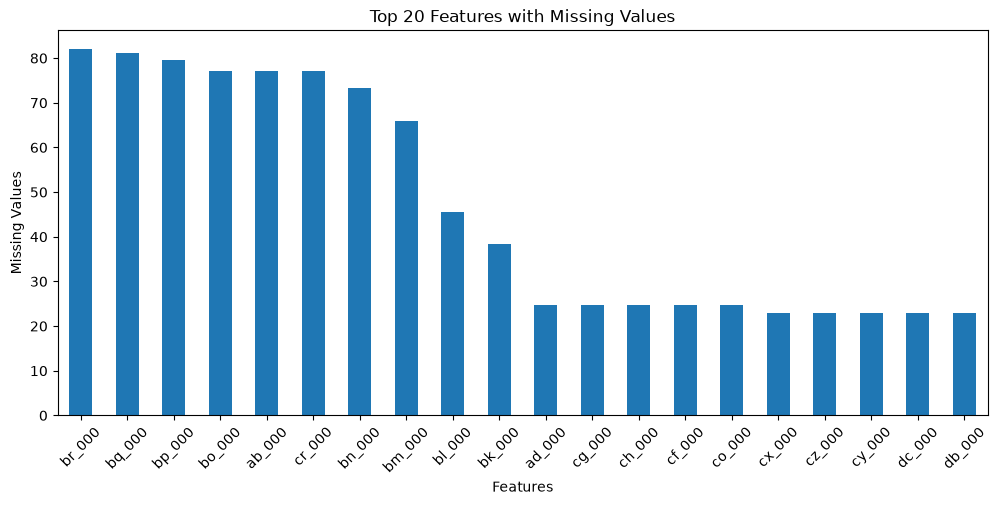

In [15]:
missing_percentage.sort_values(ascending=False).head(20).plot(kind="bar",figsize=(12,5))

plt.title("Top 20 Features with Missing Values")
plt.xlabel("Features")
plt.ylabel("Missing Values")
plt.xticks(rotation=45)
plt.show()

## 9. Feature Distribution

The dataset contains 170 sensor features.

Instead of plotting all 170 features, we will look at a few selected features.

In [16]:
features_to_plot = [ "aa_000","ac_000","ag_000","ah_000", "ay_000"]

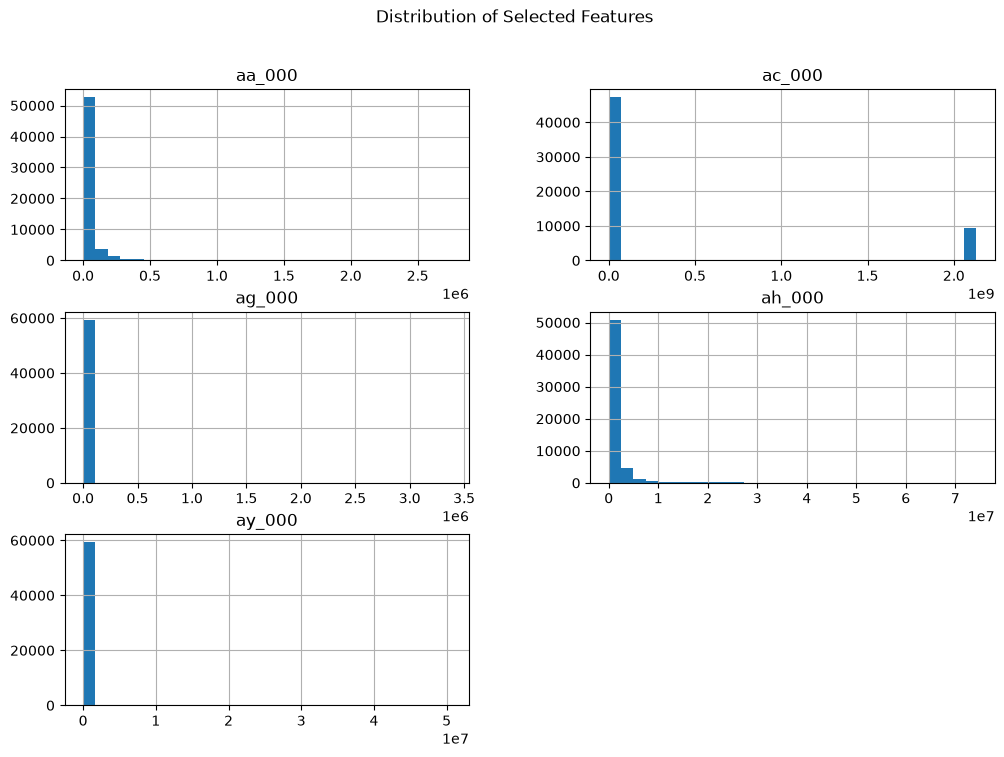

In [17]:
df_eda[features_to_plot].hist(figsize=(12, 8),bins=30)

plt.suptitle("Distribution of Selected Features")

plt.show()

## 10. Outlier Analysis

A boxplot helps us identify unusually high or low values.

We will check some selected sensor features.

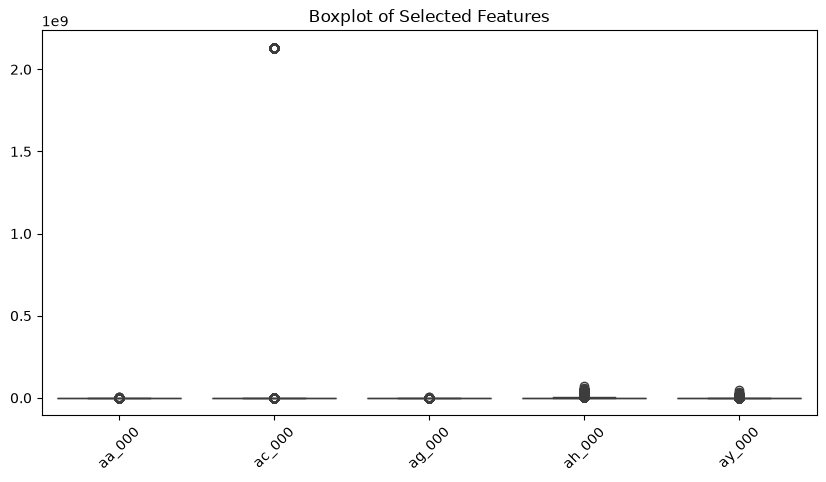

In [18]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_eda[features_to_plot])

plt.title("Boxplot of Selected Features")
plt.xticks(rotation=45)

plt.show()